In [2]:
import pandas as pd

fact = pd.read_csv("sql fact file.csv")

In [3]:
print(fact.columns.tolist())

['TripID', 'RouteKey', 'BusKey', 'TimeKey', 'PerfKey', 'StartTime', 'EndTime', 'FuelConsumed', 'Distance', 'TargetTime', 'ActualTime', 'DelayAnalysis', 'OperatingCostPerKM', 'PassengerCount', 'EngineTemperature', 'RPM', 'FuelRate', 'IdleDuration', 'AverageSpeed', 'BrakeEvents', 'OTPFlag']


In [4]:
fact['StartTime'] = pd.to_datetime(fact['StartTime'])

ValueError: time data "23-08-2025 10:16" doesn't match format "%m-%d-%Y %H:%M", at position 1. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [5]:
fact['StartTime'] = pd.to_datetime(
    fact['StartTime'],
    format='%d-%m-%Y %H:%M'
)

In [6]:
fact['Date'] = fact['StartTime'].dt.date

daily_delay = (
    fact.groupby('Date')
        .size()
        .reset_index(name='DelayCount')
)

print(daily_delay.head())
print(daily_delay.shape)

         Date  DelayCount
0  2025-01-01          45
1  2025-01-02          56
2  2025-01-03          56
3  2025-01-04          56
4  2025-01-05          72
(365, 2)


In [7]:
daily_delay.to_csv(
    "daily_delay_frequency.csv",
    index=False
)

In [8]:
fact['Hour'] = fact['StartTime'].dt.hour

hourly_delay = (
    fact.groupby('Hour')
        .size()
        .reset_index(name='DelayCount')
)

print(hourly_delay)

    Hour  DelayCount
0      0         864
1      1         834
2      2         811
3      3         863
4      4         827
5      5         812
6      6         849
7      7         858
8      8         842
9      9         818
10    10         832
11    11         839
12    12         883
13    13         837
14    14         831
15    15         831
16    16         848
17    17         846
18    18         784
19    19         804
20    20         778
21    21         827
22    22         836
23    23         846


In [9]:
hourly_delay.to_csv(
    "hourly_delay_frequency.csv",
    index=False
)

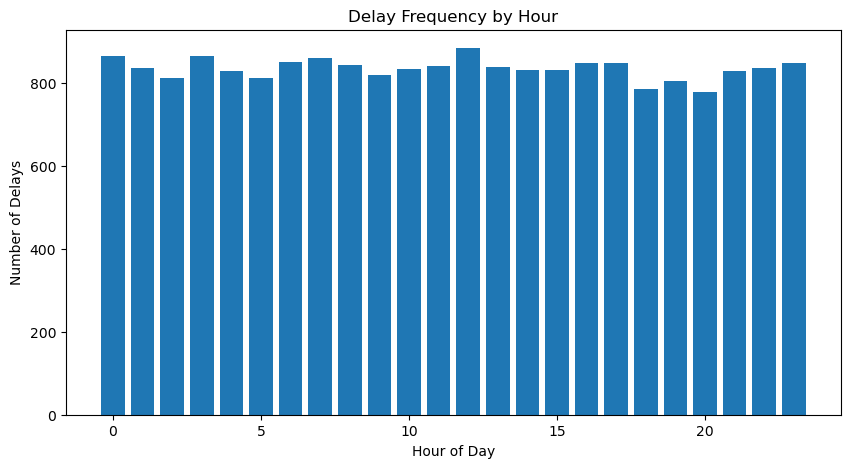

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(hourly_delay['Hour'],
        hourly_delay['DelayCount'])

plt.title('Delay Frequency by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Delays')

plt.show()

In [11]:
print(daily_delay.head())
print(daily_delay.shape)

         Date  DelayCount
0  2025-01-01          45
1  2025-01-02          56
2  2025-01-03          56
3  2025-01-04          56
4  2025-01-05          72
(365, 2)


In [12]:
print(hourly_delay)

    Hour  DelayCount
0      0         864
1      1         834
2      2         811
3      3         863
4      4         827
5      5         812
6      6         849
7      7         858
8      8         842
9      9         818
10    10         832
11    11         839
12    12         883
13    13         837
14    14         831
15    15         831
16    16         848
17    17         846
18    18         784
19    19         804
20    20         778
21    21         827
22    22         836
23    23         846


In [13]:
print(hourly_delay.shape)

(24, 2)


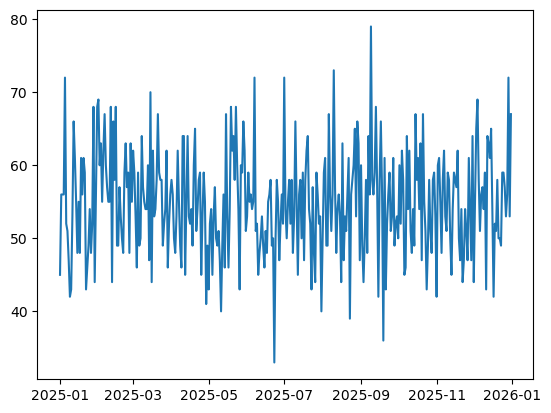

In [14]:
plt.plot(daily_delay['Date'],
         daily_delay['DelayCount'])

<BarContainer object of 24 artists>

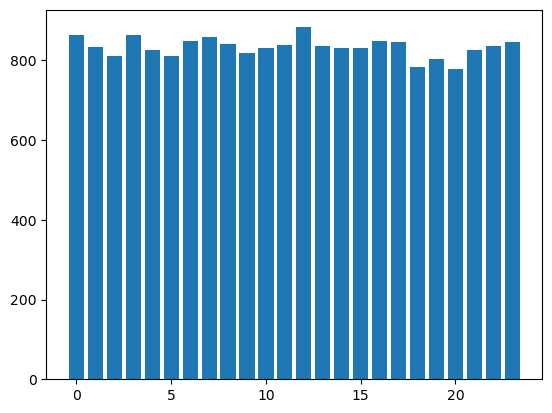

In [15]:
plt.bar(hourly_delay['Hour'],
        hourly_delay['DelayCount'])

<BarContainer object of 24 artists>

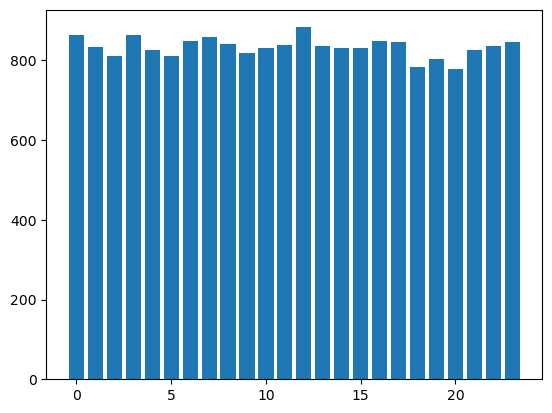

In [16]:
plt.bar(hourly_delay['Hour'],
        hourly_delay['DelayCount'])

In [17]:
print(fact.shape)

(20000, 23)


In [18]:
print(fact.columns.tolist())

['TripID', 'RouteKey', 'BusKey', 'TimeKey', 'PerfKey', 'StartTime', 'EndTime', 'FuelConsumed', 'Distance', 'TargetTime', 'ActualTime', 'DelayAnalysis', 'OperatingCostPerKM', 'PassengerCount', 'EngineTemperature', 'RPM', 'FuelRate', 'IdleDuration', 'AverageSpeed', 'BrakeEvents', 'OTPFlag', 'Date', 'Hour']
